In [5]:
import sys, os
# Erzwingt den Hauptpfad
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.db_connect import load_sql, get_engine

In [6]:
import sys
import os
from sqlalchemy import text

# Pfad-Setup
sys.path.append(os.path.abspath('..'))
from src.db_connect import get_engine

engine = get_engine()
sql_file_path = '../sql/t_create_cohort_respiratory.sql'

print("Starte Erstellung der Lungen-Kohorte...")

try:
    with open(sql_file_path, 'r', encoding='utf-8') as f:
        full_sql = f.read()

    # WICHTIG: Das Skript in einzelne Befehle zerlegen (am Semikolon)
    # Wir filtern leere Strings heraus, die durch das letzte Semikolon entstehen
    sql_commands = [cmd.strip() for cmd in full_sql.split(';') if cmd.strip()]

    with engine.begin() as conn: # .begin() startet eine Transaktion und macht automatisch ein commit
        for command in sql_commands:
            print(f"Führe aus: {command[:50]}...") # Zeigt den Anfang des Befehls an
            conn.execute(text(command))
    
    print("✅ Erfolg: Tabelle 'cohort_respiratory' und Index wurden erstellt!")

except Exception as e:
    print(f"❌ Fehler aufgetreten:\n{e}")

Starte Erstellung der Lungen-Kohorte...
Führe aus: /* Datei: sql/create_cohort_respiratory.sql
   Zwe...
Führe aus: -- 2. Neue Tabelle erstellen
CREATE TABLE cohort_r...
Führe aus: -- 3. Index erstellen
CREATE INDEX idx_resp_hadm O...
✅ Erfolg: Tabelle 'cohort_respiratory' und Index wurden erstellt!


In [3]:
import pandas as pd
# Da du 'engine' schon in der Zelle davor definiert hast, kannst du sie direkt nutzen
df = pd.read_sql("SELECT * FROM cohort_respiratory", engine)

print(f"Daten erfolgreich geladen. Patienten in der Kohorte: {len(df)}")
display(df.head())

Daten erfolgreich geladen. Patienten in der Kohorte: 7492


,subject_id,hadm_id,admittime,dischtime,gender,age,intervention_ventilation,outcome_death,los_days
0,357,174486,2197-12-06 07:13:00,2198-01-03 14:00:00,M,62.7,1,0,28.28
1,357,145674,2198-08-02 04:49:00,2198-10-26 14:55:00,M,63.4,1,0,85.42
2,357,117876,2199-12-21 22:37:00,2200-01-18 11:45:00,M,64.8,1,0,27.55
3,91,121205,2177-04-23 00:08:00,2177-05-10 15:16:00,F,81.6,1,1,17.63
4,101,175533,2196-09-26 18:36:00,2196-10-12 13:17:00,M,82.2,1,1,15.78


In [ ]:
import pandas as pd

# 1. Daten laden
df = pd.read_sql("SELECT * FROM cohort_respiratory", engine)

# 2. Erstellen der Tabelle: Beatmung vs. Verstorben
# Wir gruppieren nach der Intervention und zählen die Todesfälle
summary_table = df.groupby('intervention_ventilation').agg(
    Gesamtanzahl=('subject_id', 'count'),
    Verstorben=('outcome_death', 'sum')
).reset_index()

# 3. Berechne die Sterberate in Prozent
summary_table['Sterberate_Prozent'] = (summary_table['Verstorben'] / summary_table['Gesamtanzahl'] * 100).round(2)

# 4. Namen für die Lesbarkeit anpassen
summary_table['intervention_ventilation'] = summary_table['intervention_ventilation'].map({1: 'Beatmet', 0: 'Nicht beatmet'})

print("Übersicht: Mechanische Beatmung vs. Sterblichkeit")
display(summary_table)

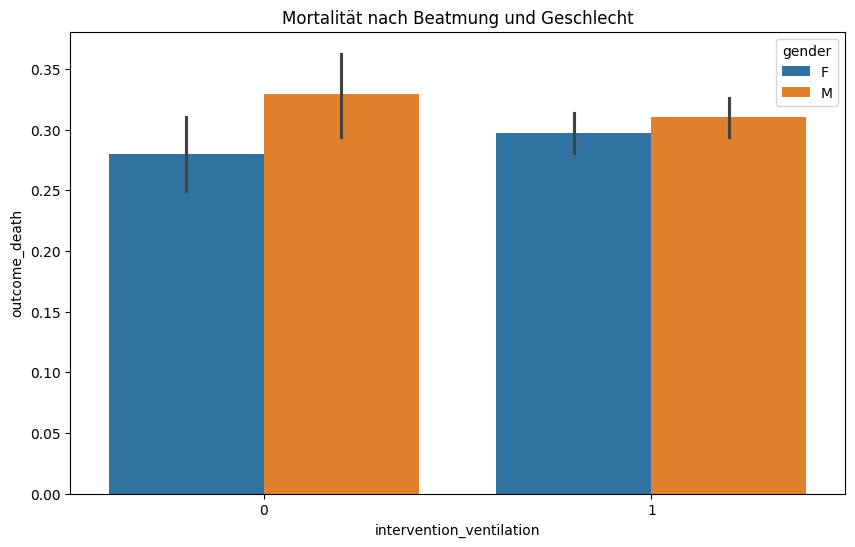

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Beispiel: Sterblichkeit nach Geschlecht und Beatmung visualisieren
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='intervention_ventilation', y='outcome_death', hue='gender')
plt.title('Mortalität nach Beatmung und Geschlecht')
plt.show()

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Daten laden (falls nicht schon im Speicher)
df = pd.read_sql("SELECT * FROM cohort_respiratory", engine)

# Zusammenfassung erstellen
gender_summary = df.groupby('gender').agg(
    Anzahl=('subject_id', 'count'),
    Alter_Schnitt=('age', 'mean'),
    Sterberate_Prozent=('outcome_death', lambda x: x.mean() * 100)
).round(2)

print("Demografie nach Geschlecht:")
display(gender_summary)

Demografie nach Geschlecht:


,Anzahl,Alter_Schnitt,Sterberate_Prozent
gender,,,
F,3471,83.89,29.33
M,4021,73.84,31.41
